# Modelling Precision while Correcting Errors

In this notebook we use the rough shape of the precision estimate curve when annotating errors using D-UCB for edge sampling to try to fit a curve estimating precision after a small number of annotated edges.

We pick a curve that looks similar in shape to the precision curves, and then see how close a fit we can get, and how many edges annotated it takes us to get that fit.

## Looking at D-UCB sampled precision curves

First let's explore what the D-UCB sampled precision estimate curves look like. We use all four explored features for D-UCB sampling, since we've already shown that there is no critical performance hit in using all features. We additionally use solutions with no merges in them, to allow easy comparison to the random and trajectory sampling methods. 

We compute the precision estimate at each sampled edge, and also show how many edges it takes before the estimate comes within a certain threshold of the true precision (and stays at or below that threshold.)

In [ ]:
import pandas as pd
import json
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [74]:
ROOT_PTH = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/ducb/no_merges_no_ws'
all_bandit_csv_pths = [os.path.join(ROOT_PTH, f) for f in os.listdir(ROOT_PTH) if f.endswith('.csv')]
ds_names = ['_'.join(os.path.basename(pth).split('_')[:2]) for pth in all_bandit_csv_pths]

all_bandits = []
for ds_name, pth in zip(ds_names, all_bandit_csv_pths, strict=True):
    df = pd.read_csv(pth)
    df = df[(df.flow > 0) & (((df.u >= 0) & (df.v >= 0)) | ((df.u == -2) & (df.v >= 0)))]
    assert all(df.bandit_rank != -1)
    df['ds_name'] = ds_name
    df = df[[
        'ds_name',
        'u',
        'v',
        'bandit_arm',
        'bandit_rank',
        'oracle_is_correct',
        'error_type'
    ]]
    df = df.sort_values(by='bandit_rank')
    df['cum_FP'] = (df.oracle_is_correct == 0).cumsum()
    df['cum_TP'] = (df.oracle_is_correct == 1).cumsum()
    df['cum_prec_estimate'] = df['cum_TP'] / (df['cum_TP'] + df['cum_FP'])
    all_bandits.append(df)
all_bandit_df = pd.concat(all_bandits, ignore_index=True)
all_bandits.clear()

/tmp/ipykernel_233845/2569161716.py:7: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pth)
/tmp/ipykernel_233845/2569161716.py:7: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pth)
/tmp/ipykernel_233845/2569161716.py:7: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pth)
/tmp/ipykernel_233845/2569161716.py:7: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pth)
/tmp/ipykernel_233845/2569161716.py:7: DtypeWarning: Columns (16,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(pth)


In [75]:
all_bandit_df.head()

,ds_name,u,v,bandit_arm,bandit_rank,oracle_is_correct,error_type,cum_FP,cum_TP,cum_prec_estimate
0,DIC-C2DH-HeLa_02,474,490,cost,1,0,FP,1,0,0.000000
1,DIC-C2DH-HeLa_02,573,587,softmax_entropy,2,1,Correct,1,1,0.500000
2,DIC-C2DH-HeLa_02,14,26,sensitivity_diff,3,1,Correct,1,2,0.666667
3,DIC-C2DH-HeLa_02,-2,773,cost,5,1,Correct,1,3,0.750000
4,DIC-C2DH-HeLa_02,743,757,softmax_entropy,6,1,Correct,1,4,0.800000


In [76]:
# load n edges and true precision for each dataset
records = []
for ds_name in ds_names:
    ds_bandit = all_bandit_df[all_bandit_df['ds_name'] == ds_name]
    n_edges = len(ds_bandit)
    true_precision = ds_bandit['cum_prec_estimate'].iloc[-1] if n_edges > 0 else 0
    records.append({
        'ds_name': ds_name,
        'n_edges': n_edges,
        'true_precision': true_precision
    })
ds_info = pd.DataFrame(records)
true_prec_lookup = ds_info.set_index('ds_name')['true_precision']
n_edges_lookup = ds_info.set_index('ds_name')['n_edges']

# we don't care about datasets with perfect precision, and we order plots in descending order of n_edges
plot_df = all_bandit_df[all_bandit_df['ds_name'].map(true_prec_lookup) < 1.0]
col_order = ds_info[ds_info['ds_name'].isin(plot_df['ds_name'].unique())].sort_values('n_edges', ascending=False)['ds_name'].tolist()

/tmp/ipykernel_233845/3533389076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['n_sampled'] = plot_df['cum_TP'] + plot_df['cum_FP']


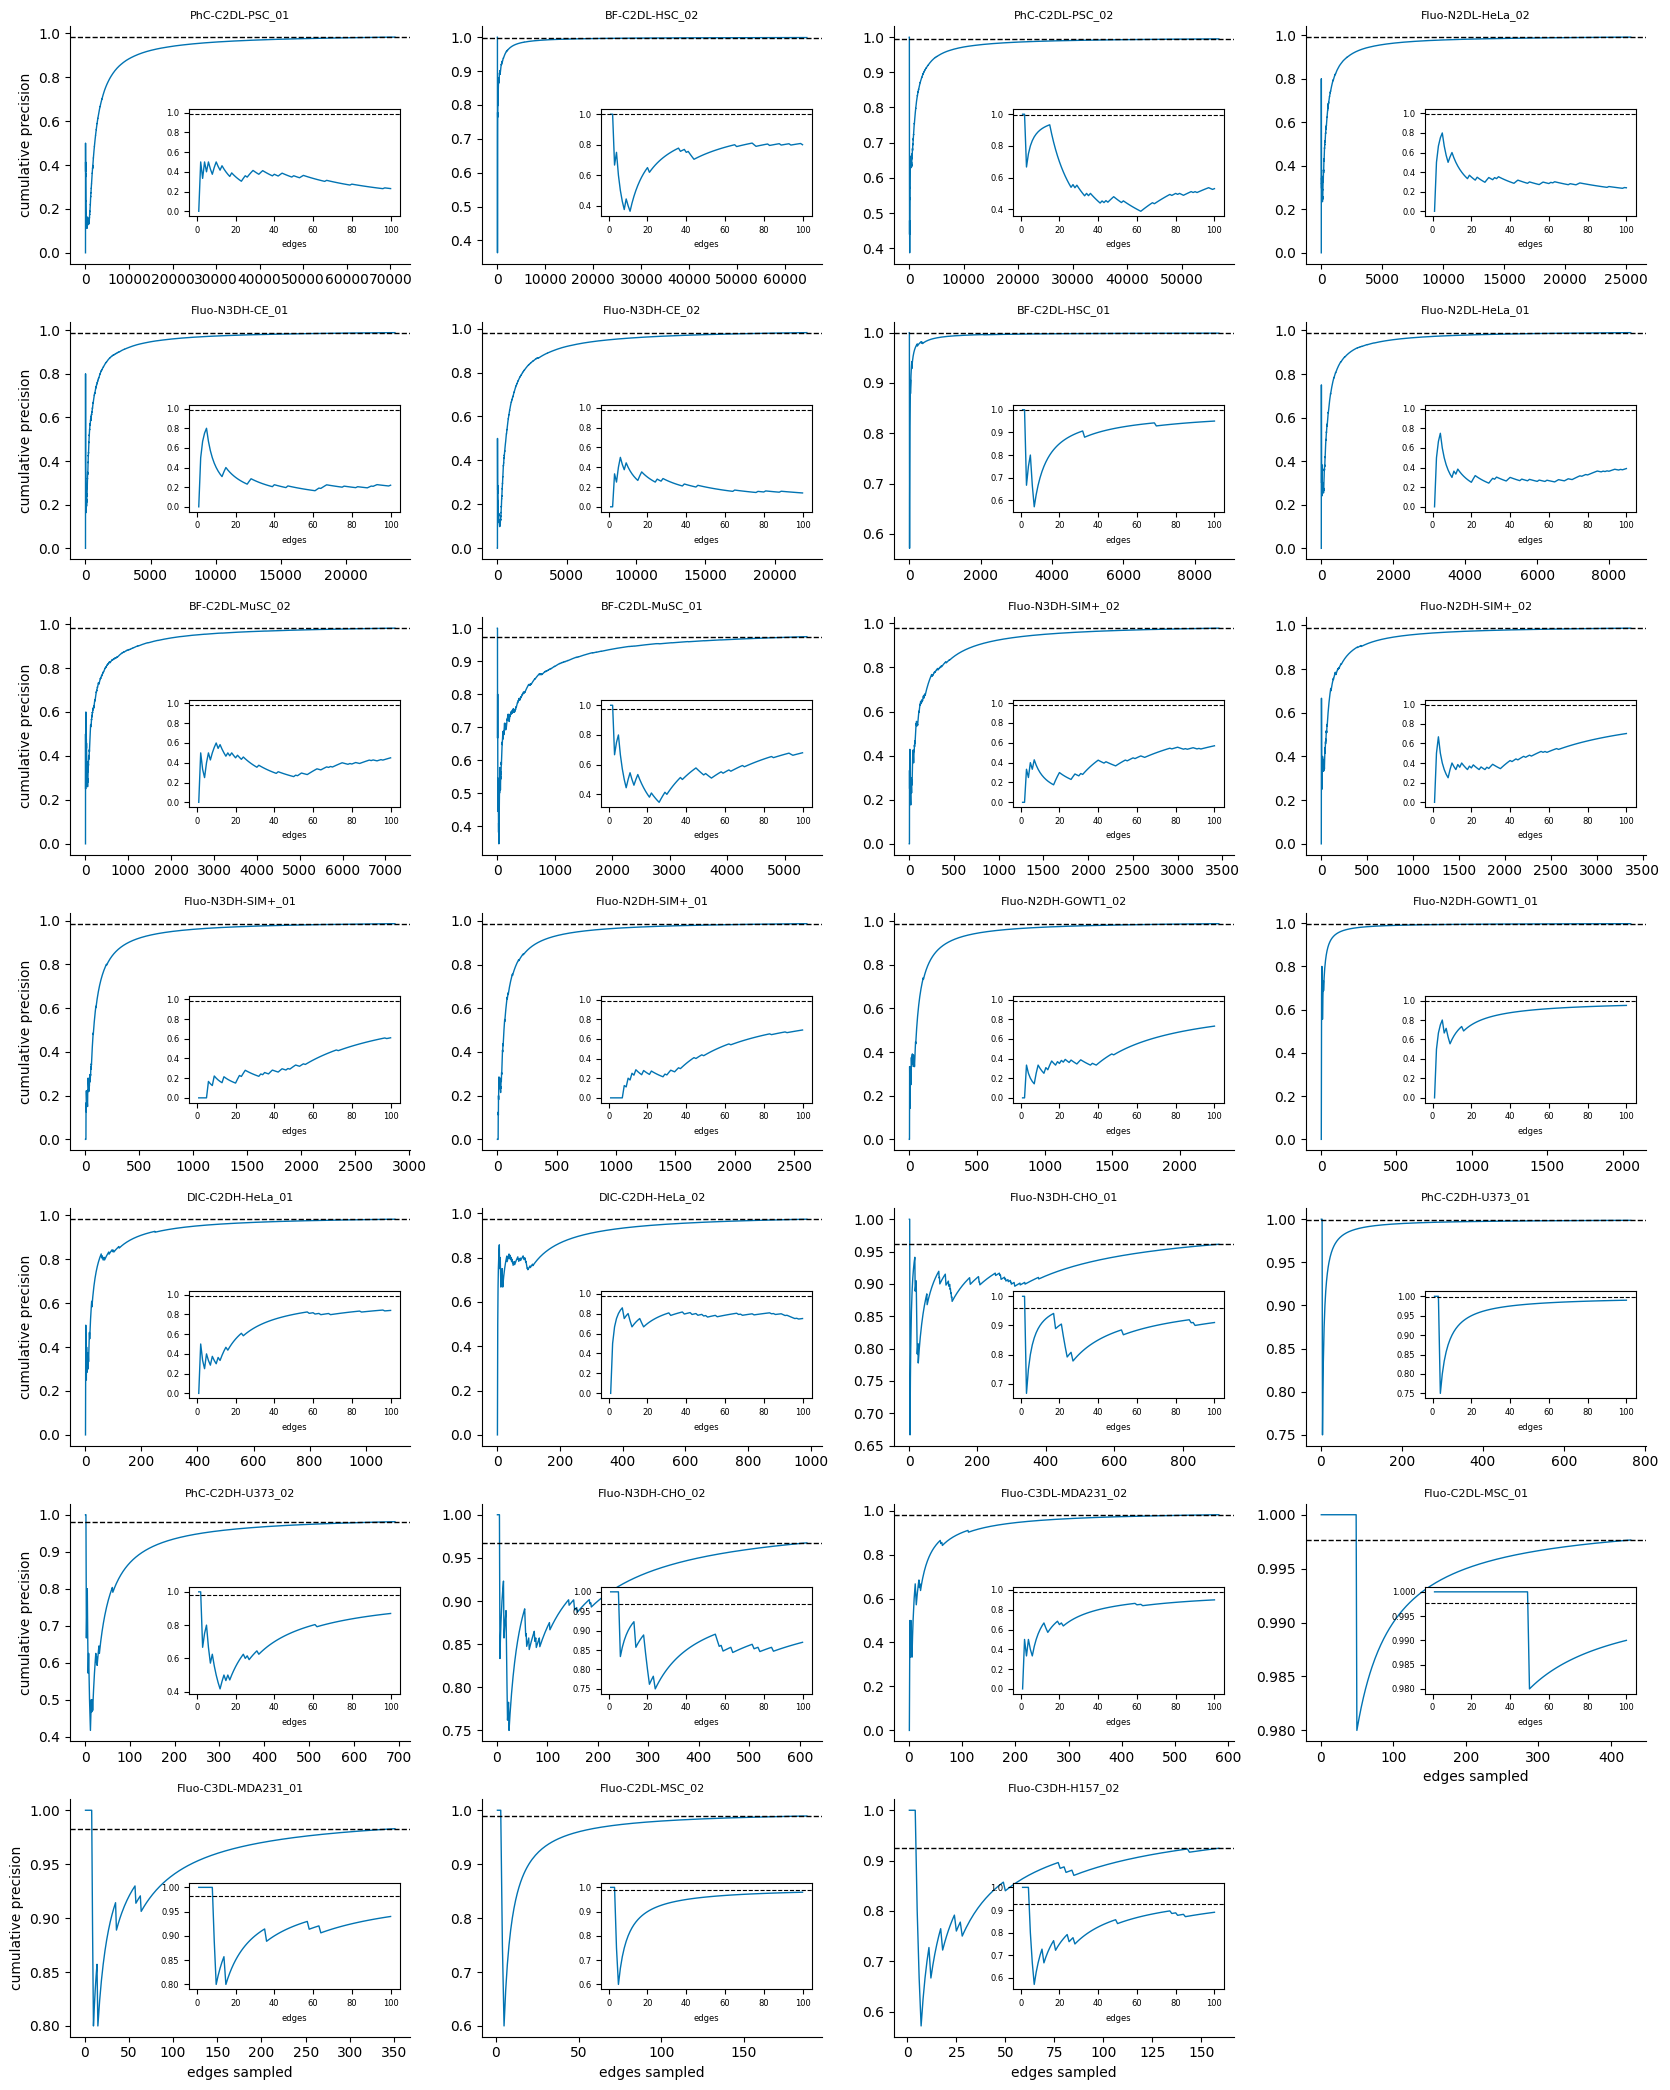

In [79]:
plot_df['n_sampled'] = plot_df['cum_TP'] + plot_df['cum_FP']

plot_color = sns.color_palette("colorblind")[0]
def plot_with_inset(data, **kwargs):
    ax = plt.gca()
    ds_name = data['ds_name'].iloc[0]
    true_p = true_prec_lookup[ds_name]

    x = data['n_sampled']
    y = data['cum_prec_estimate']

    ax.plot(x, y, linewidth=1, color=plot_color)
    ax.axhline(true_p, color='black', linestyle='--', linewidth=1)

    # inset: first 1% of edges
    # cutoff = max(1, int(0.01 * n_edges))
    sub = data[data['n_sampled'] <= 100]
    axins = ax.inset_axes([0.35, 0.20, 0.62, 0.45])
    axins.plot(sub['n_sampled'], sub['cum_prec_estimate'], linewidth=1, color=plot_color)
    axins.axhline(true_p, color='black', linestyle='--', linewidth=0.8)
    axins.set_xlabel('edges', fontsize=6)
    axins.tick_params(labelsize=6)

g = sns.FacetGrid(
    plot_df,
    col='ds_name',
    col_order=col_order,
    col_wrap=4,
    height=3,
    aspect=1.4,
    sharex=False,
    sharey=False
)
g.map_dataframe(plot_with_inset)
g.set_axis_labels('edges sampled', 'cumulative precision')
g.set_titles(col_template='{col_name}', size=8)
plt.tight_layout()
plt.show()

We can see that overall, the shape of the curves for all datasets is pretty similar, looking a little like a reciprocal function. We can also see that, given we're trying to sample errors, the precision estimate takes a long time to converge to the true value. When we zoom into the first 100 sampled edges, we can see that not only is there quite a bit of noise in the estimate, as would be expected, but the overall shape of this curve is dependent on whether the first edge was correct (meaning we start descending from precision=1), or incorrect, meaning we ascend from precision=0. This will likely affect our ability to fit a curve from a small number of samples.

## Curve Fitting

We begin with an arbitrarily chosen reciprocal curve that appears similar in shape to the precision curves plotted above. To gauge how well we theoretically could estimate precision using this curve, we first fit it using all the values in the dataset. 

In [80]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.patches as mpatches

In [81]:
def reciprocal_func(x, a, b):
    denom = x + np.multiply(a, np.exp(np.multiply(-b, x)))
    return np.divide(x, denom)

In [96]:
from scipy.optimize import OptimizeWarning
import warnings

fitted_dfs = []
fit_params = []

for ds_name in col_order:
    sub = plot_df[plot_df['ds_name'] == ds_name].copy()
    x = (sub['cum_TP'] + sub['cum_FP']).values.astype(float)
    y = sub['cum_prec_estimate'].values.astype(float)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            popt, _ = curve_fit(reciprocal_func, x, y, p0=(1.0, 0.01), bounds=(0, np.inf), maxfev=10000)
        y_fit = reciprocal_func(x, *popt)
        residuals = y - y_fit
        r_squared = 1 - np.sum(residuals ** 2) / np.sum((y - np.mean(y)) ** 2)
        fit_params.append({'ds_name': ds_name, 'a': popt[0], 'b': popt[1], 'r_squared': r_squared})
    except RuntimeError:
        y_fit = np.full_like(y, np.nan)
        fit_params.append({'ds_name': ds_name, 'a': np.nan, 'b': np.nan, 'r_squared': np.nan})

    sub['n_sampled'] = x
    sub['fitted_prec'] = y_fit
    fitted_dfs.append(sub)

plot_df = pd.concat(fitted_dfs, ignore_index=True)
fit_params_df = pd.DataFrame(fit_params)
fit_params_df

,ds_name,a,b,r_squared
0,PhC-C2DL-PSC_01,1977.849383,2.202663e-05,0.967694
1,BF-C2DL-HSC_02,29.900877,1.270244e-29,0.601509
2,PhC-C2DL-PSC_02,231.025725,4.570512e-24,0.788366
3,Fluo-N2DL-HeLa_02,265.880418,1.909370e-05,0.964520
4,Fluo-N3DH-CE_01,285.292606,3.141835e-06,0.976806
5,Fluo-N3DH-CE_02,569.692884,3.504346e-05,0.973777
6,BF-C2DL-HSC_01,2.495621,1.878909e-32,0.383544
7,Fluo-N2DL-HeLa_01,110.627116,8.664188e-05,0.956414
8,BF-C2DL-MuSC_02,119.000131,2.022893e-16,0.938361
9,BF-C2DL-MuSC_01,86.536174,1.321665e-24,0.675515


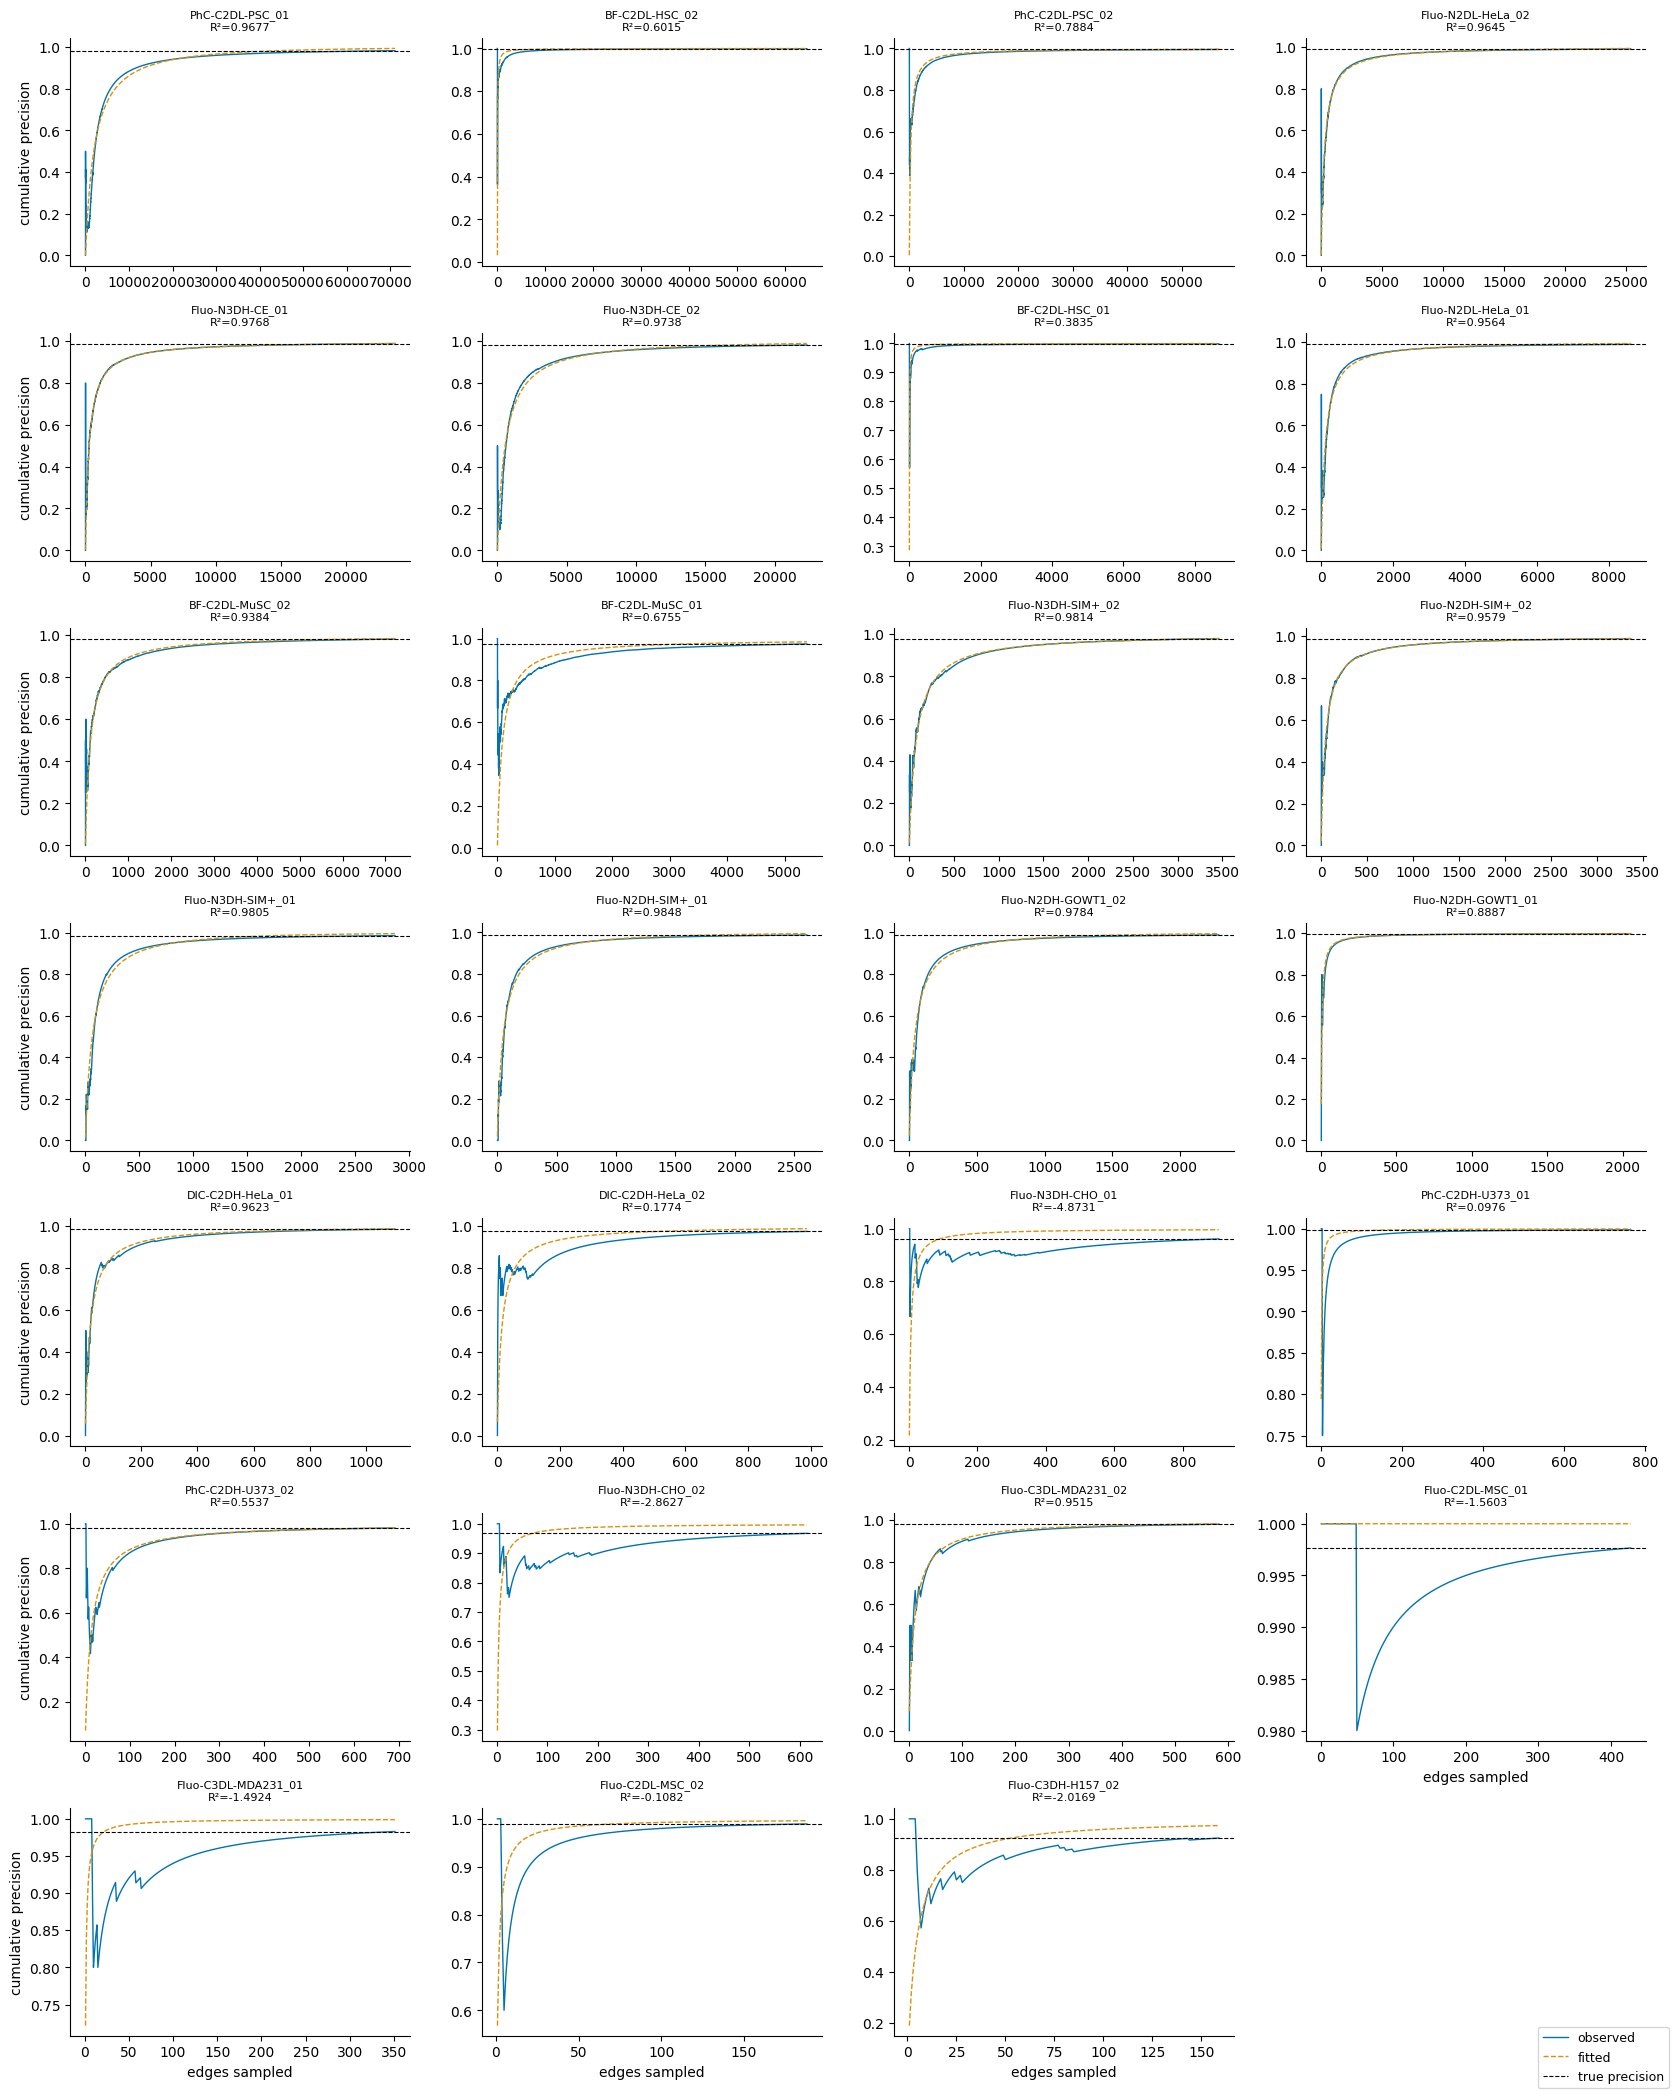

In [97]:
fit_color = sns.color_palette("colorblind")[1]

def plot_fit(data, **kwargs):
    ax = plt.gca()
    ds_name = data['ds_name'].iloc[0]
    true_p = true_prec_lookup[ds_name]
    r2 = fit_params_df.set_index('ds_name').loc[ds_name, 'r_squared']

    ax.plot(data['n_sampled'], data['cum_prec_estimate'], linewidth=1, color=plot_color, label='observed')
    ax.plot(data['n_sampled'], data['fitted_prec'], linewidth=1, color=fit_color, linestyle='--', label='fitted')
    ax.axhline(true_p, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f"{ds_name}\nR²={r2:.4f}", size=8)

g = sns.FacetGrid(
    plot_df,
    col='ds_name',
    col_order=col_order,
    col_wrap=4,
    height=3,
    aspect=1.4,
    sharex=False,
    sharey=False
)
g.map_dataframe(plot_fit)
g.set_axis_labels('edges sampled', 'cumulative precision')

legend_handles = [
    plt.Line2D([0], [0], color=plot_color, linewidth=1, label='observed'),
    plt.Line2D([0], [0], color=fit_color, linewidth=1, linestyle='--', label='fitted'),
    plt.Line2D([0], [0], color='black', linewidth=0.8, linestyle='--', label='true precision'),
]
g.figure.legend(handles=legend_handles, loc='lower right', fontsize=9, bbox_to_anchor=(1.0, 0.0))
plt.tight_layout()
plt.show()

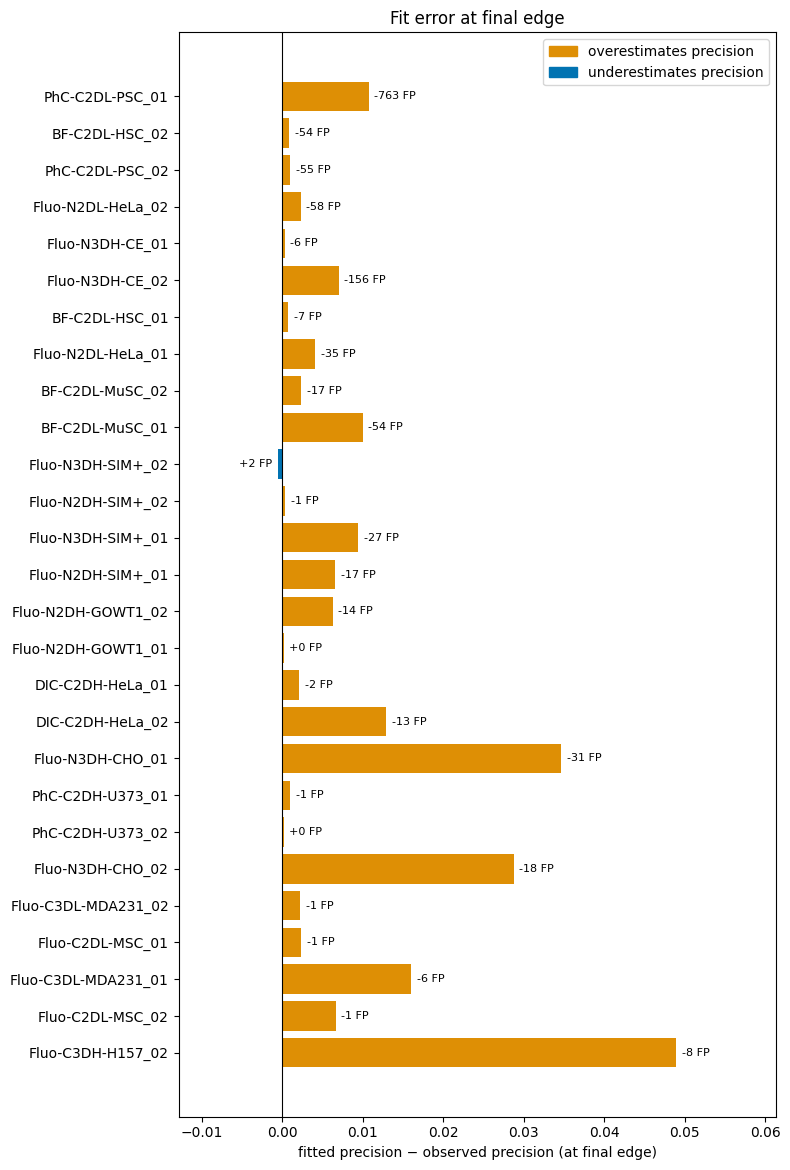

,ds_name,cum_prec_estimate,fitted_prec,cum_FP,n_edges,prec_difference,fp_difference
0,Fluo-C3DH-H157_02,0.924528,0.973518,12,159,0.048989,-8
1,Fluo-C2DL-MSC_02,0.989362,0.995969,2,188,0.006608,-1
2,Fluo-C3DL-MDA231_01,0.982906,0.998902,6,351,0.015996,-6
3,Fluo-C2DL-MSC_01,0.997658,1.000000,1,427,0.002342,-1
4,Fluo-C3DL-MDA231_02,0.981100,0.983300,11,582,0.002200,-1
5,Fluo-N3DH-CHO_02,0.967427,0.996167,20,614,0.028741,-18
6,PhC-C2DH-U373_02,0.981214,0.981386,13,692,0.000172,0
7,PhC-C2DH-U373_01,0.998693,0.999661,1,765,0.000968,-1
8,Fluo-N3DH-CHO_01,0.961326,0.996008,35,905,0.034682,-31
9,DIC-C2DH-HeLa_02,0.972672,0.985596,27,988,0.012924,-13


In [98]:
last_edge = plot_df.groupby('ds_name').last().reset_index()[['ds_name', 'cum_prec_estimate', 'fitted_prec', 'cum_FP']]
last_edge = last_edge.merge(ds_info[['ds_name', 'n_edges']], on='ds_name')
last_edge['prec_difference'] = last_edge['fitted_prec'] - last_edge['cum_prec_estimate']
last_edge['fp_difference'] = (last_edge['n_edges'] * (last_edge['cum_prec_estimate'] - last_edge['fitted_prec'])).round().astype(int)
last_edge = last_edge.set_index('ds_name').reindex(reversed(col_order)).reset_index()

fig, ax = plt.subplots(figsize=(8, len(last_edge) * 0.4 + 1))
bar_colors = [fit_color if d >= 0 else plot_color for d in last_edge['prec_difference']]
bars = ax.barh(last_edge['ds_name'], last_edge['prec_difference'], color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('fitted precision − observed precision (at final edge)')
ax.set_title('Fit error at final edge')
ax.margins(x=0.25)

for bar, fp_diff in zip(bars, last_edge['fp_difference']):
    x = bar.get_width()
    sign = '+' if fp_diff >= 0 else ''
    ax.annotate(
        f'{sign}{fp_diff} FP',
        xy=(x, bar.get_y() + bar.get_height() / 2),
        xytext=(4 if x >= 0 else -4, 0), textcoords='offset points',
        ha='left' if x >= 0 else 'right', va='center', fontsize=8,
    )

legend_handles = [
    mpatches.Patch(color=fit_color, label='overestimates precision'),
    mpatches.Patch(color=plot_color, label='underestimates precision'),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()

last_edge

## Smoothing and fitting

We apply Gaussian smoothing to the raw precision curve before fitting, to reduce the effect of per-edge noise. We then fit the reciprocal curve to the smoothed values using all data, and compare the fit quality to the unsmoothed fit.

In [106]:
from scipy.ndimage import gaussian_filter1d

SIGMA = 5  # in units of edges — tune as needed

# smooth per dataset and fit to smoothed values
smooth_fit_params = []

for ds_name in col_order:
    mask = plot_df['ds_name'] == ds_name
    y_raw = plot_df.loc[mask, 'cum_prec_estimate'].values
    x = plot_df.loc[mask, 'n_sampled'].values.astype(float)

    y_smooth = gaussian_filter1d(y_raw, sigma=SIGMA)
    plot_df.loc[mask, 'smoothed_prec'] = y_smooth

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            popt, _ = curve_fit(
                reciprocal_func,
                x,
                y_smooth,
                p0=[1.0, 0.01],
                bounds=(0, np.inf),
                maxfev=10000
            )
        y_fit = reciprocal_func(x, *popt)
        residuals = y_smooth - y_fit
        r2 = 1 - np.sum(residuals ** 2) / np.sum((y_smooth - np.mean(y_smooth)) ** 2)
        smooth_fit_params.append({'ds_name': ds_name, 'a': popt[0], 'b': popt[1], 'r_squared': r2})
    except RuntimeError:
        y_fit = np.full_like(x, np.nan)
        smooth_fit_params.append({'ds_name': ds_name, 'a': np.nan, 'b': np.nan, 'r_squared': np.nan})

    plot_df.loc[mask, 'smoothed_fitted_prec'] = y_fit

smooth_fit_params_df = pd.DataFrame(smooth_fit_params)
smooth_fit_params_df

,ds_name,a,b,r_squared
0,PhC-C2DL-PSC_01,1977.840849,2.202625e-05,0.967883
1,BF-C2DL-HSC_02,29.606240,2.862030e-29,0.623111
2,PhC-C2DL-PSC_02,230.972607,4.713250e-24,0.790576
3,Fluo-N2DL-HeLa_02,265.854563,1.907585e-05,0.967453
4,Fluo-N3DH-CE_01,285.260684,3.125583e-06,0.979844
5,Fluo-N3DH-CE_02,569.692246,3.504249e-05,0.974554
6,BF-C2DL-HSC_01,2.460712,4.191092e-28,0.566922
7,Fluo-N2DL-HeLa_01,110.574597,8.634570e-05,0.962377
8,BF-C2DL-MuSC_02,119.033587,1.909703e-16,0.943016
9,BF-C2DL-MuSC_01,86.381216,1.696246e-24,0.687168


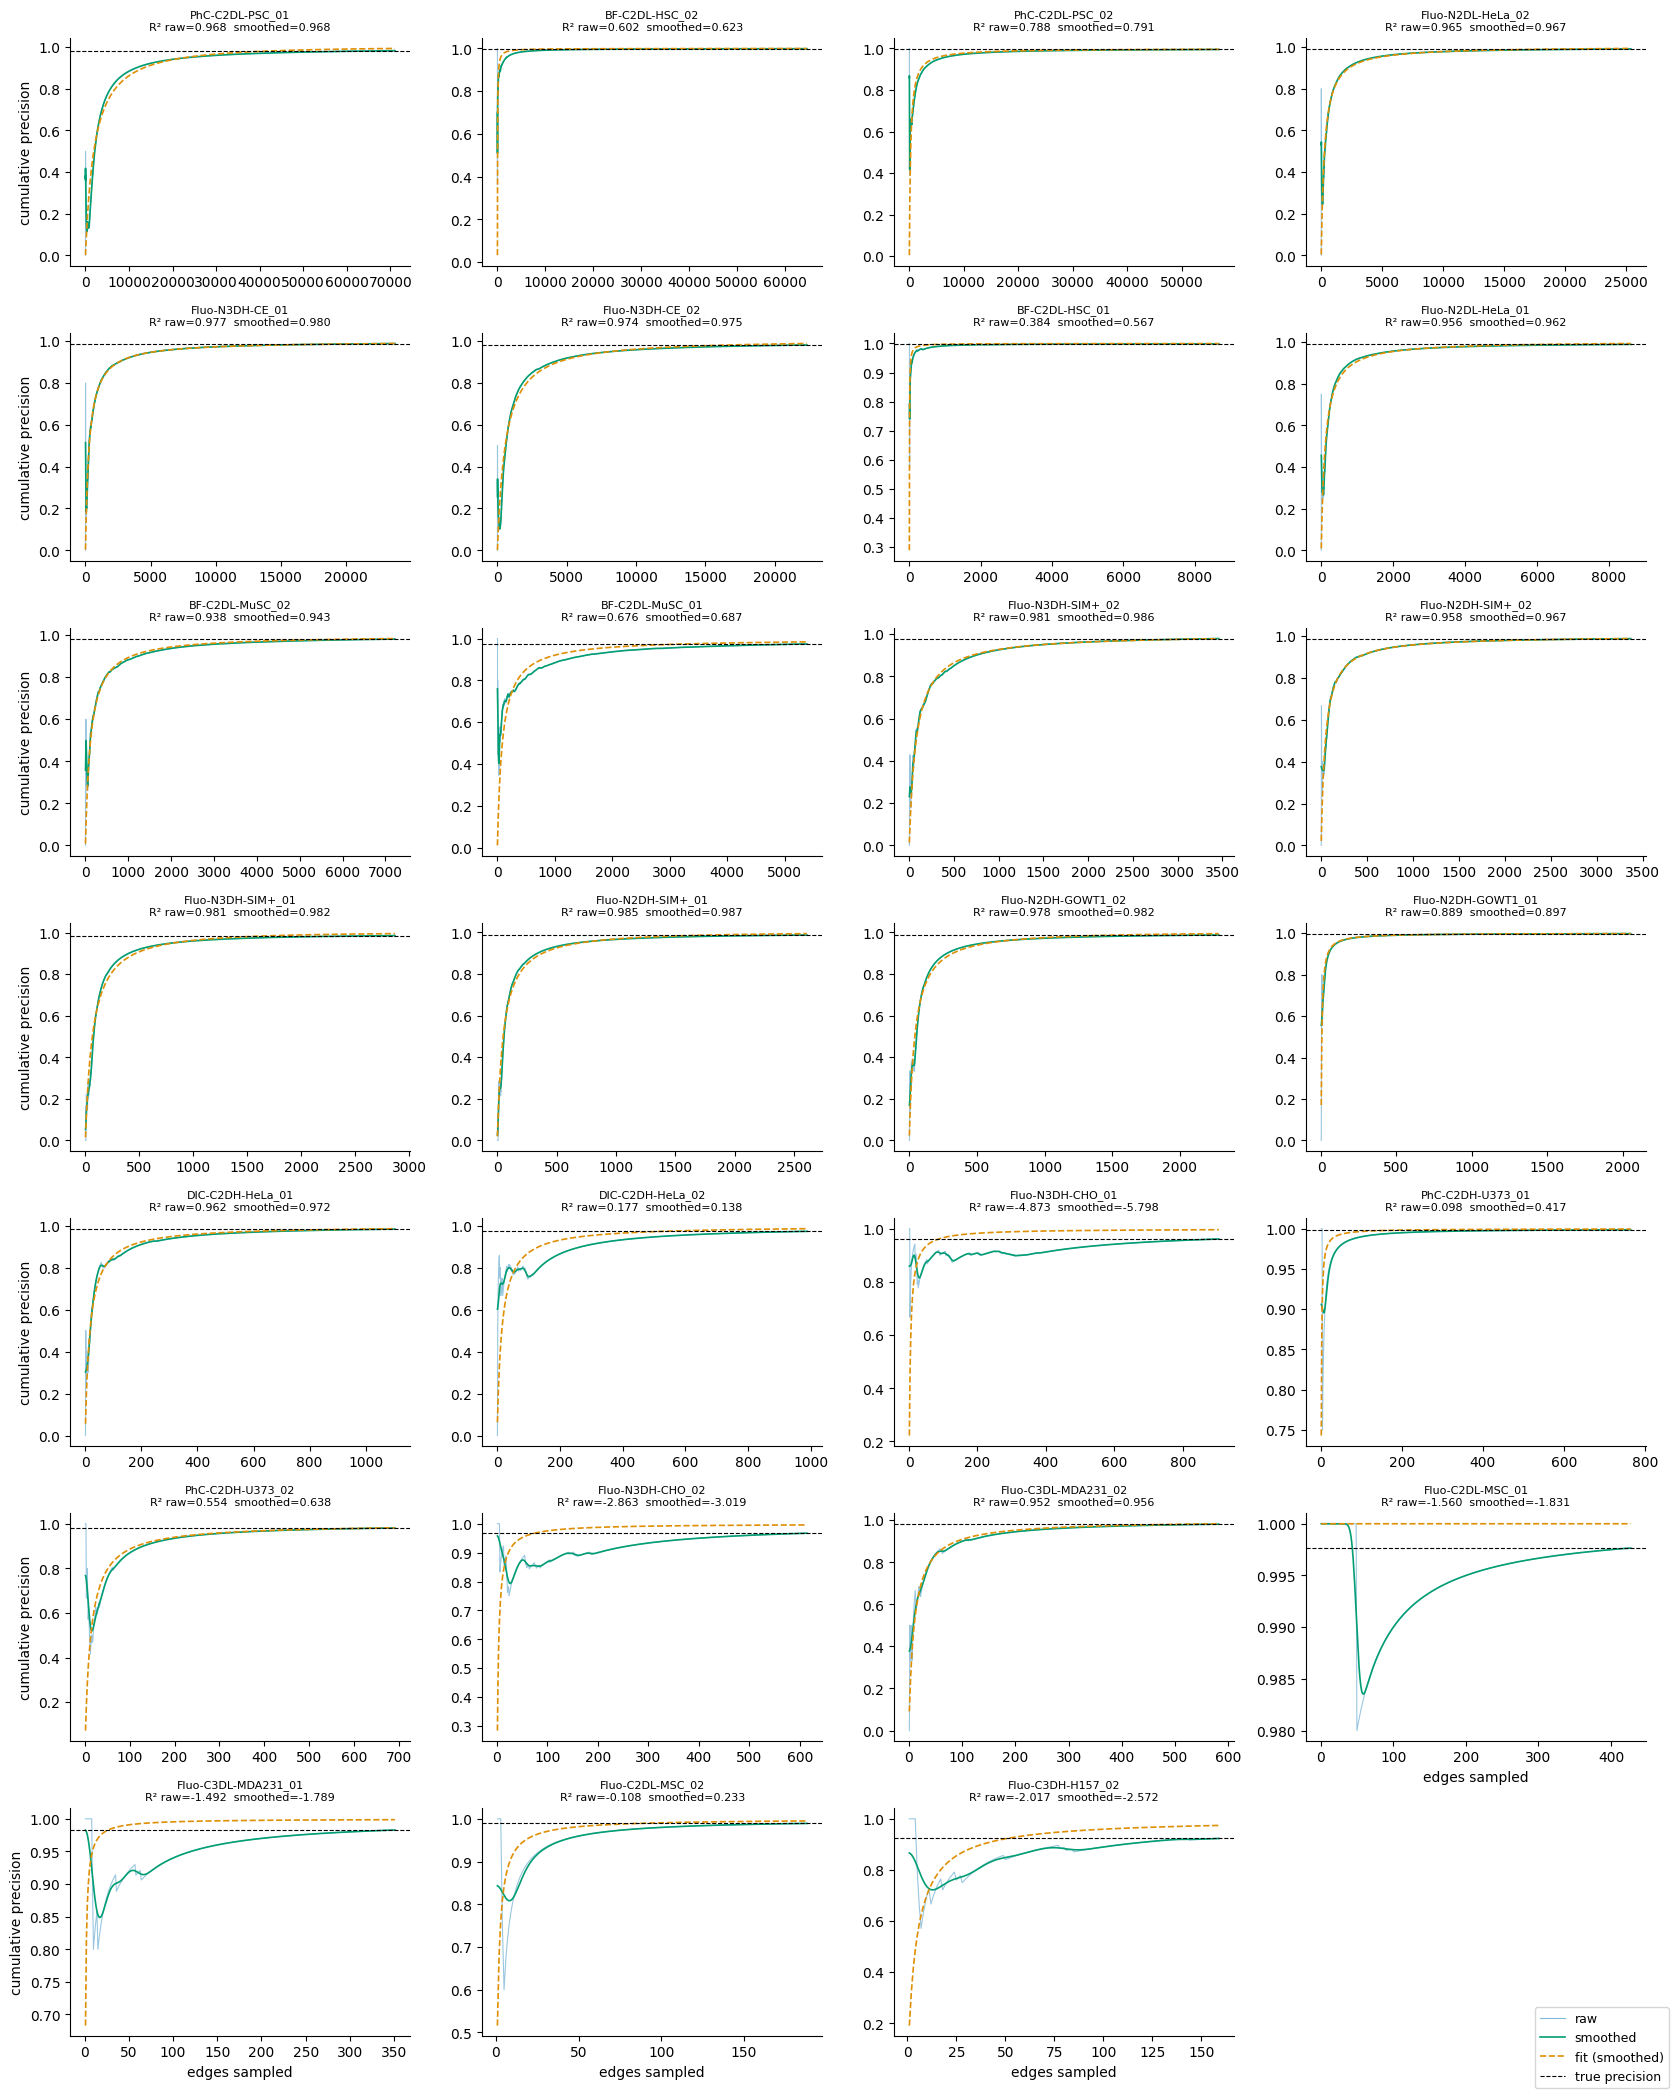

In [107]:
smooth_color = sns.color_palette("colorblind")[2]

def plot_smoothed_fit(data, **kwargs):
    ax = plt.gca()
    ds_name = data['ds_name'].iloc[0]
    true_p = true_prec_lookup[ds_name]
    r2_raw = fit_params_df.set_index('ds_name').loc[ds_name, 'r_squared']
    r2_smooth = smooth_fit_params_df.set_index('ds_name').loc[ds_name, 'r_squared']

    ax.plot(data['n_sampled'], data['cum_prec_estimate'], linewidth=0.8, color=plot_color, alpha=0.4, label='raw')
    ax.plot(data['n_sampled'], data['smoothed_prec'], linewidth=1.2, color=smooth_color, label='smoothed')
    ax.plot(data['n_sampled'], data['smoothed_fitted_prec'], linewidth=1.2, color=fit_color, linestyle='--', label='fit (smoothed)')
    ax.axhline(true_p, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f"{ds_name}\nR² raw={r2_raw:.3f}  smoothed={r2_smooth:.3f}", size=8)

g = sns.FacetGrid(
    plot_df,
    col='ds_name',
    col_order=col_order,
    col_wrap=4,
    height=3,
    aspect=1.4,
    sharex=False,
    sharey=False
)
g.map_dataframe(plot_smoothed_fit)
g.set_axis_labels('edges sampled', 'cumulative precision')

legend_handles = [
    plt.Line2D([0], [0], color=plot_color, alpha=0.5, linewidth=0.8, label='raw'),
    plt.Line2D([0], [0], color=smooth_color, linewidth=1.2, label='smoothed'),
    plt.Line2D([0], [0], color=fit_color, linewidth=1.2, linestyle='--', label='fit (smoothed)'),
    plt.Line2D([0], [0], color='black', linewidth=0.8, linestyle='--', label='true precision'),
]
g.figure.legend(handles=legend_handles, loc='lower right', fontsize=9, bbox_to_anchor=(1.0, 0.0))
plt.tight_layout()
plt.show()

Smoothing has improved our fit for the larger datasets, but we're still struggling with the issue of the shape of the curve at the beginning not matching our chosen curve. 

## Excluding edges before the minimal precision

We now check whether excluding an initial number of edges from the fit, where the curve is volatile, and affected by whether our starting edge is TP or FP, improves the fit. In this theoretical case, we simply find the global minimal precision, and exclude all prior edges from the fit. We cannot know this while sampling, but it can give us an estimate of how good our fit could be.

In [ ]:
global_min_fit_params = []

for ds_name in col_order:
    mask = plot_df['ds_name'] == ds_name
    y_smooth = plot_df.loc[mask, 'smoothed_prec'].values
    x = plot_df.loc[mask, 'n_sampled'].values.astype(float)

    # global minimum of the smoothed curve
    min_idx = int(np.argmin(y_smooth))
    min_edge = int(x[min_idx])
    plot_df.loc[mask, 'global_min_idx'] = min_idx

    x_fit = x[min_idx:] - x[min_idx]  # shift to start at 0
    y_fit_input = y_smooth[min_idx:]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            popt, _ = curve_fit(
                reciprocal_func,
                x_fit,
                y_fit_input,
                p0=[1.0, 0.01],
                bounds=(0, np.inf),
                maxfev=10000
            )
        y_fit = reciprocal_func(x_fit, *popt)
        residuals = y_fit_input - y_fit
        r2 = 1 - np.sum(residuals ** 2) / np.sum((y_fit_input - np.mean(y_fit_input)) ** 2)
        global_min_fit_params.append({
            'ds_name': ds_name, 'a': popt[0], 'b': popt[1],
            'r_squared': r2, 'min_edge': min_edge,
        })
    except RuntimeError:
        y_fit = np.full_like(x_fit, np.nan)
        global_min_fit_params.append({
            'ds_name': ds_name, 'a': np.nan, 'b': np.nan,
            'r_squared': np.nan, 'min_edge': min_edge,
        })

    plot_df.loc[mask, 'global_min_fitted_prec'] = np.concatenate([
        np.full(min_idx, np.nan), y_fit
    ])

global_min_fit_params_df = pd.DataFrame(global_min_fit_params)
global_min_fit_params_df

,ds_name,a,b,r_squared,min_edge
0,PhC-C2DL-PSC_01,1636.627895,1.245118e-05,0.987280,333
1,BF-C2DL-HSC_02,25.924935,9.300796e-33,0.546801,12
2,PhC-C2DL-PSC_02,214.997690,6.130519e-24,0.812518,61
3,Fluo-N2DL-HeLa_02,215.116225,1.613144e-17,0.983828,98
4,Fluo-N3DH-CE_01,256.808115,3.645181e-18,0.991535,58
5,Fluo-N3DH-CE_02,436.032907,3.484889e-06,0.998506,159
6,BF-C2DL-HSC_01,1.789646,1.145047e-27,0.180382,9
7,Fluo-N2DL-HeLa_01,79.167933,1.765676e-18,0.982253,59
8,BF-C2DL-MuSC_02,99.293474,7.297986e-21,0.933737,50
9,BF-C2DL-MuSC_01,78.150820,8.470006e-24,0.650188,25


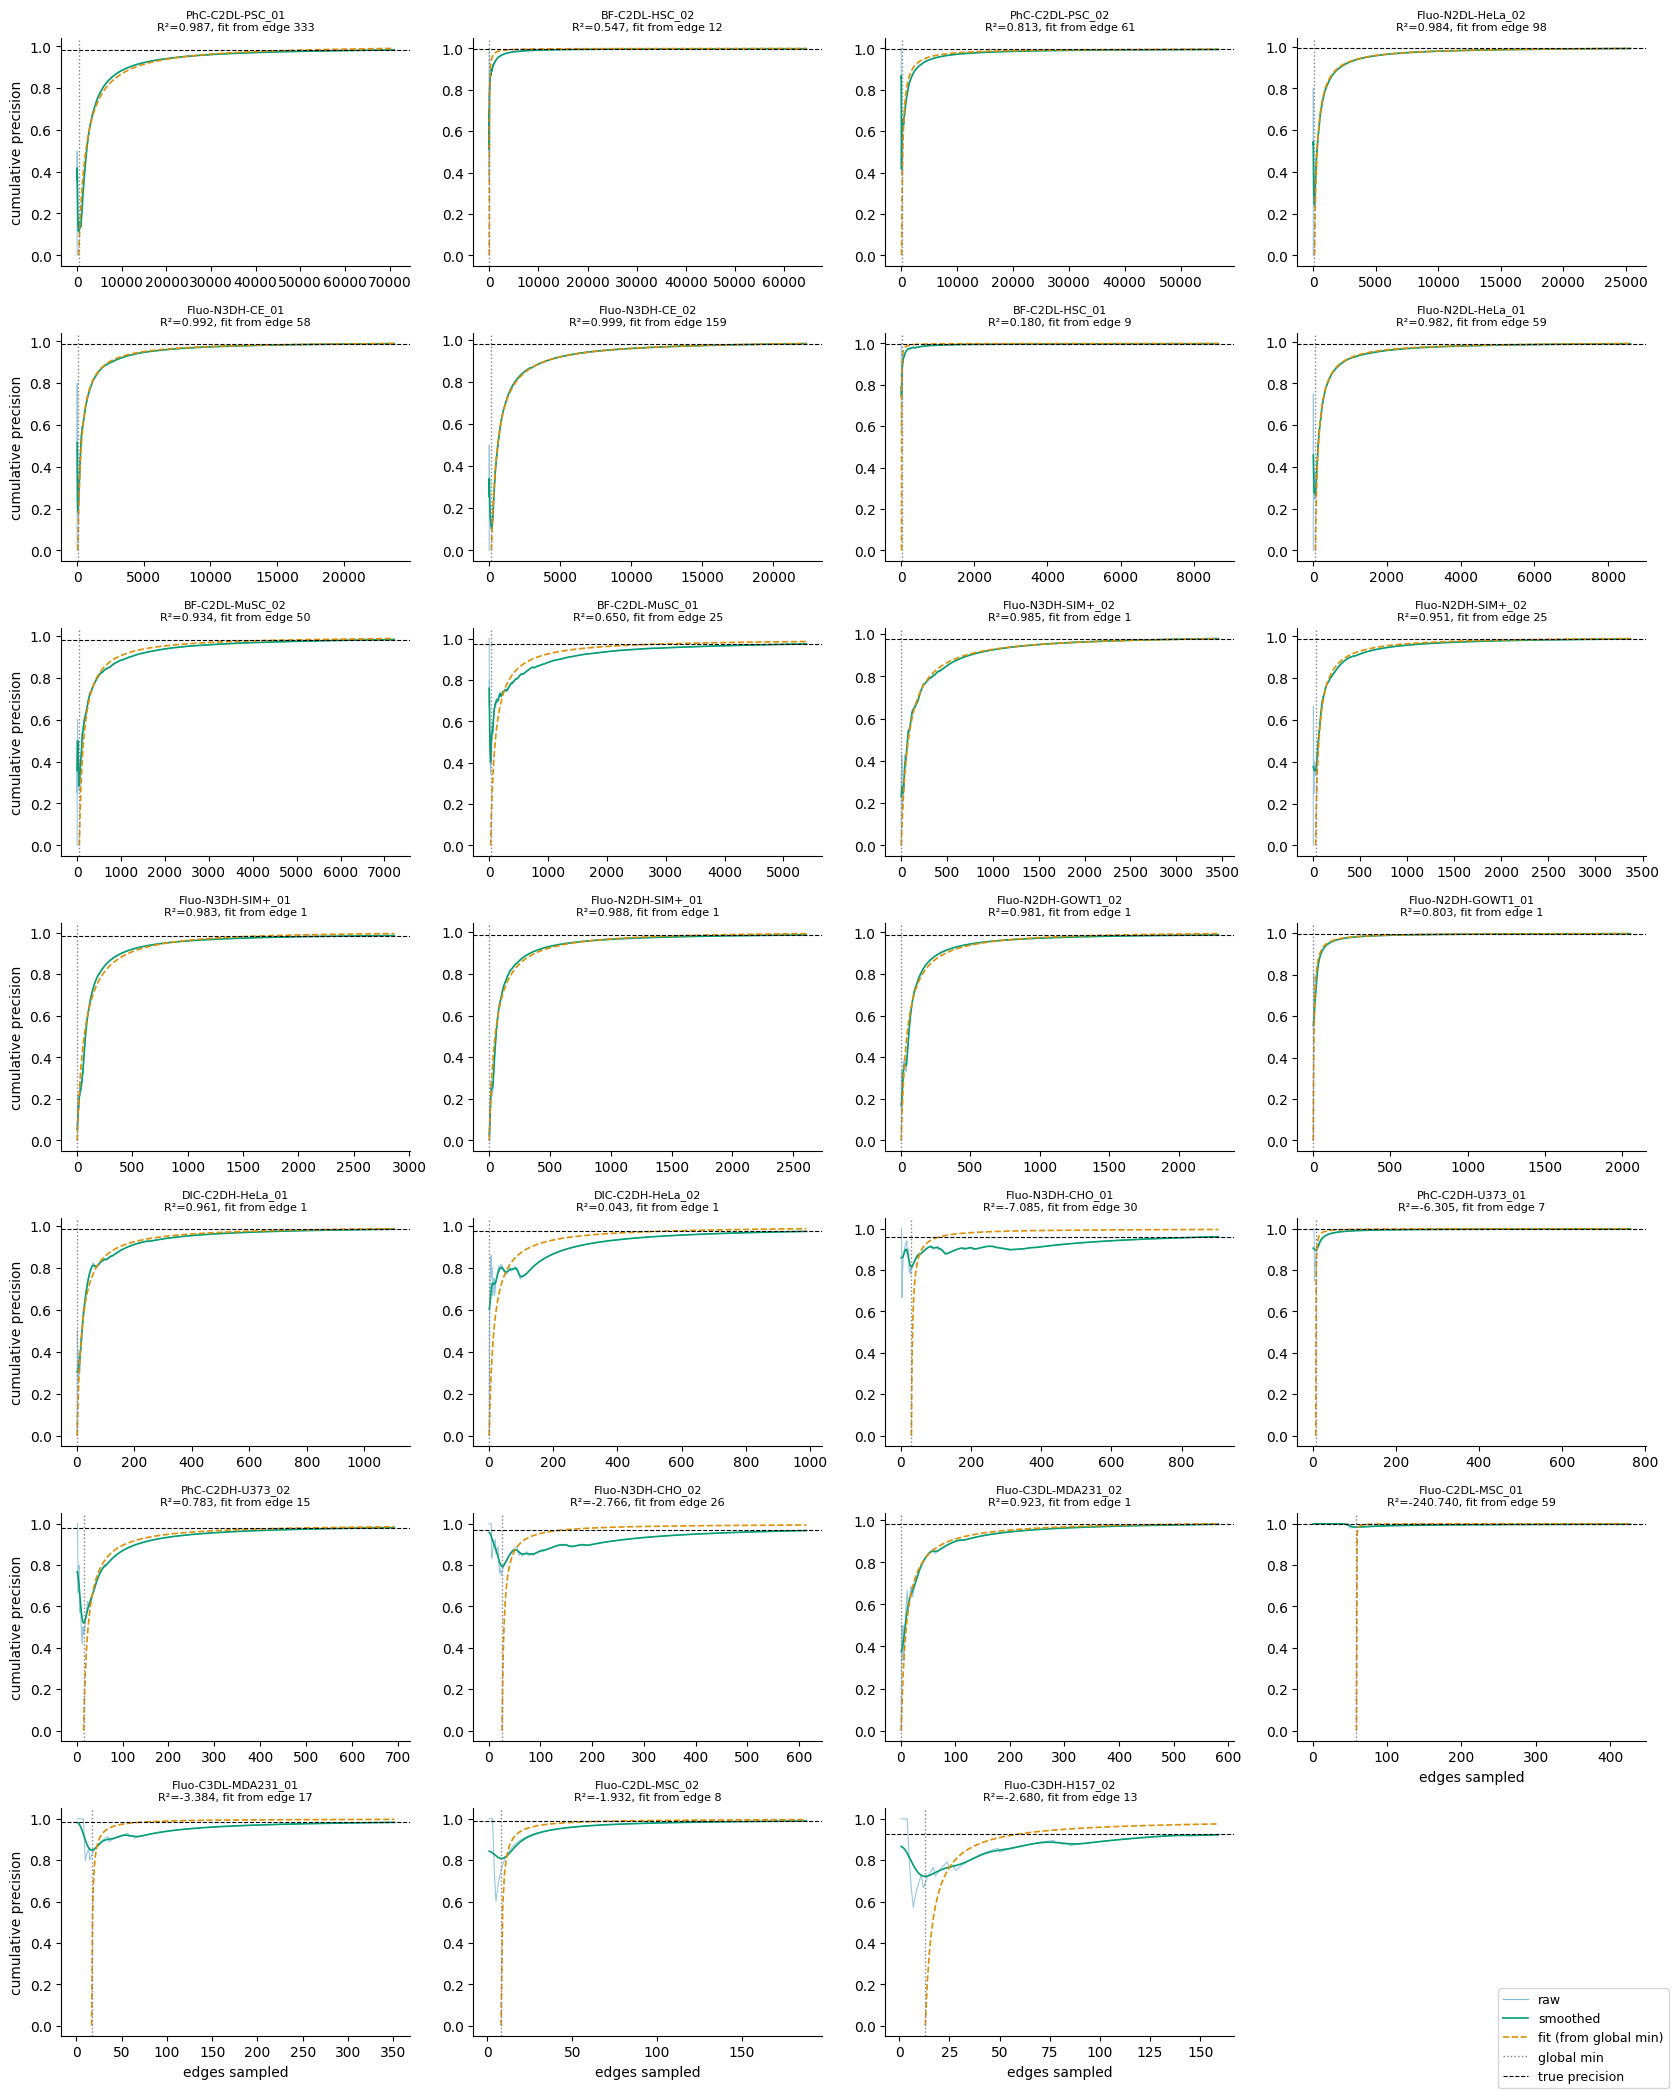

In [108]:
global_min_lookup = global_min_fit_params_df.set_index('ds_name')

def plot_global_min_fit(data, **kwargs):
    ax = plt.gca()
    ds_name = data['ds_name'].iloc[0]
    true_p = true_prec_lookup[ds_name]
    r2 = global_min_lookup.loc[ds_name, 'r_squared']
    min_edge = global_min_lookup.loc[ds_name, 'min_edge']

    ax.plot(data['n_sampled'], data['cum_prec_estimate'], linewidth=0.8, color=plot_color, alpha=0.4)
    ax.plot(data['n_sampled'], data['smoothed_prec'], linewidth=1.2, color=smooth_color)
    ax.plot(data['n_sampled'], data['global_min_fitted_prec'], linewidth=1.2, color=fit_color, linestyle='--')
    ax.axvline(min_edge, color='grey', linestyle=':', linewidth=1)
    ax.axhline(true_p, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f"{ds_name}\nR²={r2:.3f}, fit from edge {min_edge}", size=8)

g = sns.FacetGrid(
    plot_df,
    col='ds_name',
    col_order=col_order,
    col_wrap=4,
    height=3,
    aspect=1.4,
    sharex=False,
    sharey=False
)
g.map_dataframe(plot_global_min_fit)
g.set_axis_labels('edges sampled', 'cumulative precision')

legend_handles = [
    plt.Line2D([0], [0], color=plot_color, alpha=0.5, linewidth=0.8, label='raw'),
    plt.Line2D([0], [0], color=smooth_color, linewidth=1.2, label='smoothed'),
    plt.Line2D([0], [0], color=fit_color, linewidth=1.2, linestyle='--', label='fit (from global min)'),
    plt.Line2D([0], [0], color='grey', linewidth=1, linestyle=':', label='global min'),
    plt.Line2D([0], [0], color='black', linewidth=0.8, linestyle='--', label='true precision'),
]
g.figure.legend(handles=legend_handles, loc='lower right', fontsize=9, bbox_to_anchor=(1.0, 0.0))
plt.tight_layout()
plt.show()

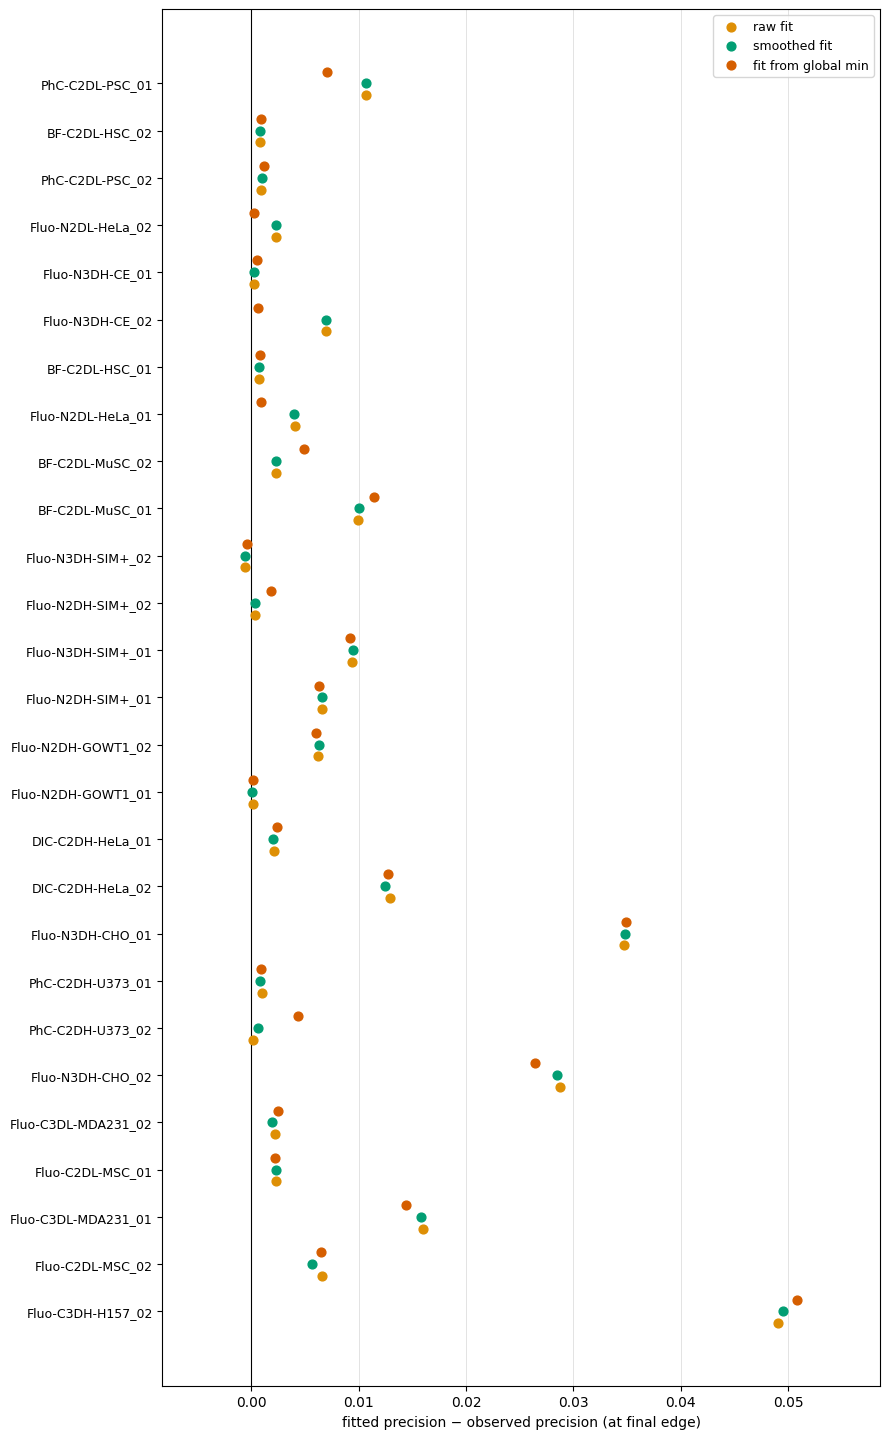

In [109]:
final_edge = plot_df.groupby('ds_name').last().reset_index()[[
    'ds_name', 'cum_prec_estimate', 'fitted_prec', 'smoothed_fitted_prec', 'global_min_fitted_prec'
]]
final_edge['raw_error']       = final_edge['fitted_prec']           - final_edge['cum_prec_estimate']
final_edge['smooth_error']    = final_edge['smoothed_fitted_prec']  - final_edge['cum_prec_estimate']
final_edge['global_min_error']= final_edge['global_min_fitted_prec']- final_edge['cum_prec_estimate']
final_edge = final_edge.set_index('ds_name').reindex(reversed(col_order)).reset_index()

method_colors = {
    'raw fit':          fit_color,
    'smoothed fit':     smooth_color,
    'fit from global min': sns.color_palette("colorblind")[3],
}
error_cols = {
    'raw fit':          'raw_error',
    'smoothed fit':     'smooth_error',
    'fit from global min': 'global_min_error',
}
offsets = {'raw fit': -0.25, 'smoothed fit': 0, 'fit from global min': 0.25}

fig, ax = plt.subplots(figsize=(9, len(col_order) * 0.5 + 1))

for method, color in method_colors.items():
    y = [i + offsets[method] for i in range(len(final_edge))]
    ax.scatter(final_edge[error_cols[method]], y, color=color, label=method, zorder=3, s=40)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(final_edge)))
ax.set_yticklabels(final_edge['ds_name'], fontsize=9)
ax.set_xlabel('fitted precision − observed precision (at final edge)')
ax.legend(fontsize=9)
ax.grid(axis='x', linewidth=0.5, alpha=0.5)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## Fitting with few samples

We now want to see how many edges the user has to annotate before they can get a good precision estimate. We assume that while the user is still finding plenty of errors to correct, they are less interested in a precision estimate. This assumption also works for us because we are unlikely to be able to provide a good fit from sampled edges before the error-rate starts dropping and we start accumulating more TP edges.

We therefore look at different window sizes of edges e.g. 20, 50, 100 and compute the rolling number of FP edges detected in that window. Then, we examine different thresholds of error rates. Once the rolling error rate has fallen below the given threshold, this gives us a "reasonable" number of edges to use for fitting. We then fit using all edges up until this point.

In [122]:
from collections import defaultdict

grouped_dfs = []
for ds_name in col_order:
    ds_ucb = plot_df[plot_df.ds_name == ds_name]
    for window_size in [20, 50, 100]:
        edge_is_fp = (ds_ucb['oracle_is_correct'] == 0).astype(int)
        ds_ucb[f'rolling_incorrect_{window_size}'] = edge_is_fp.rolling(window=window_size, min_periods=1).sum()

    grouped_dfs.append(ds_ucb)

all_grouped = pd.concat(grouped_dfs, axis=0)

# find the first index where 'rolling_incorrect_sum' drops below threshold
rate_dicts = defaultdict(dict)
for window_size in [20, 50, 100]:
    rolling_col_name = f'rolling_incorrect_{window_size}'
    for threshold in [20, 10, 5]:
        threshold_rate = threshold / 100 * window_size
        sample_col_name = f'sample_start_{window_size}_{threshold}'
        rate_thresholds = all_grouped.groupby('ds_name').apply(
            lambda g: g.loc[((g[rolling_col_name] < threshold_rate) & (g['n_sampled'] > window_size)), 'n_sampled'].iloc[0]
            if (g[rolling_col_name] < threshold_rate).any() else None
        ).reset_index(name=sample_col_name)
        rate_dict = rate_thresholds.to_dict(orient='records')
        rate_dict = {item['ds_name']: item[sample_col_name] for item in rate_dict}
        rate_dicts[sample_col_name] = rate_dict

/tmp/ipykernel_233845/3150492495.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds_ucb[f'rolling_incorrect_{window_size}'] = edge_is_fp.rolling(window=window_size, min_periods=1).sum()
/tmp/ipykernel_233845/3150492495.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds_ucb[f'rolling_incorrect_{window_size}'] = edge_is_fp.rolling(window=window_size, min_periods=1).sum()
/tmp/ipykernel_233845/3150492495.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

In [125]:
import pprint

pprint.pprint(rate_dicts)

defaultdict(<class 'dict'>,
            {'sample_start_100_10': {'BF-C2DL-HSC_01': 101.0,
                                     'BF-C2DL-HSC_02': 200.0,
                                     'BF-C2DL-MuSC_01': 399.0,
                                     'BF-C2DL-MuSC_02': 287.0,
                                     'DIC-C2DH-HeLa_01': 112.0,
                                     'DIC-C2DH-HeLa_02': 186.0,
                                     'Fluo-C2DL-MSC_01': 101.0,
                                     'Fluo-C2DL-MSC_02': 101.0,
                                     'Fluo-C3DH-H157_02': 106.0,
                                     'Fluo-C3DL-MDA231_01': 101.0,
                                     'Fluo-C3DL-MDA231_02': 101.0,
                                     'Fluo-N2DH-GOWT1_01': 101.0,
                                     'Fluo-N2DH-GOWT1_02': 129.0,
                                     'Fluo-N2DH-SIM+_01': 130.0,
                                     'Fluo-N2DH-SIM+_02': 141.0,
     

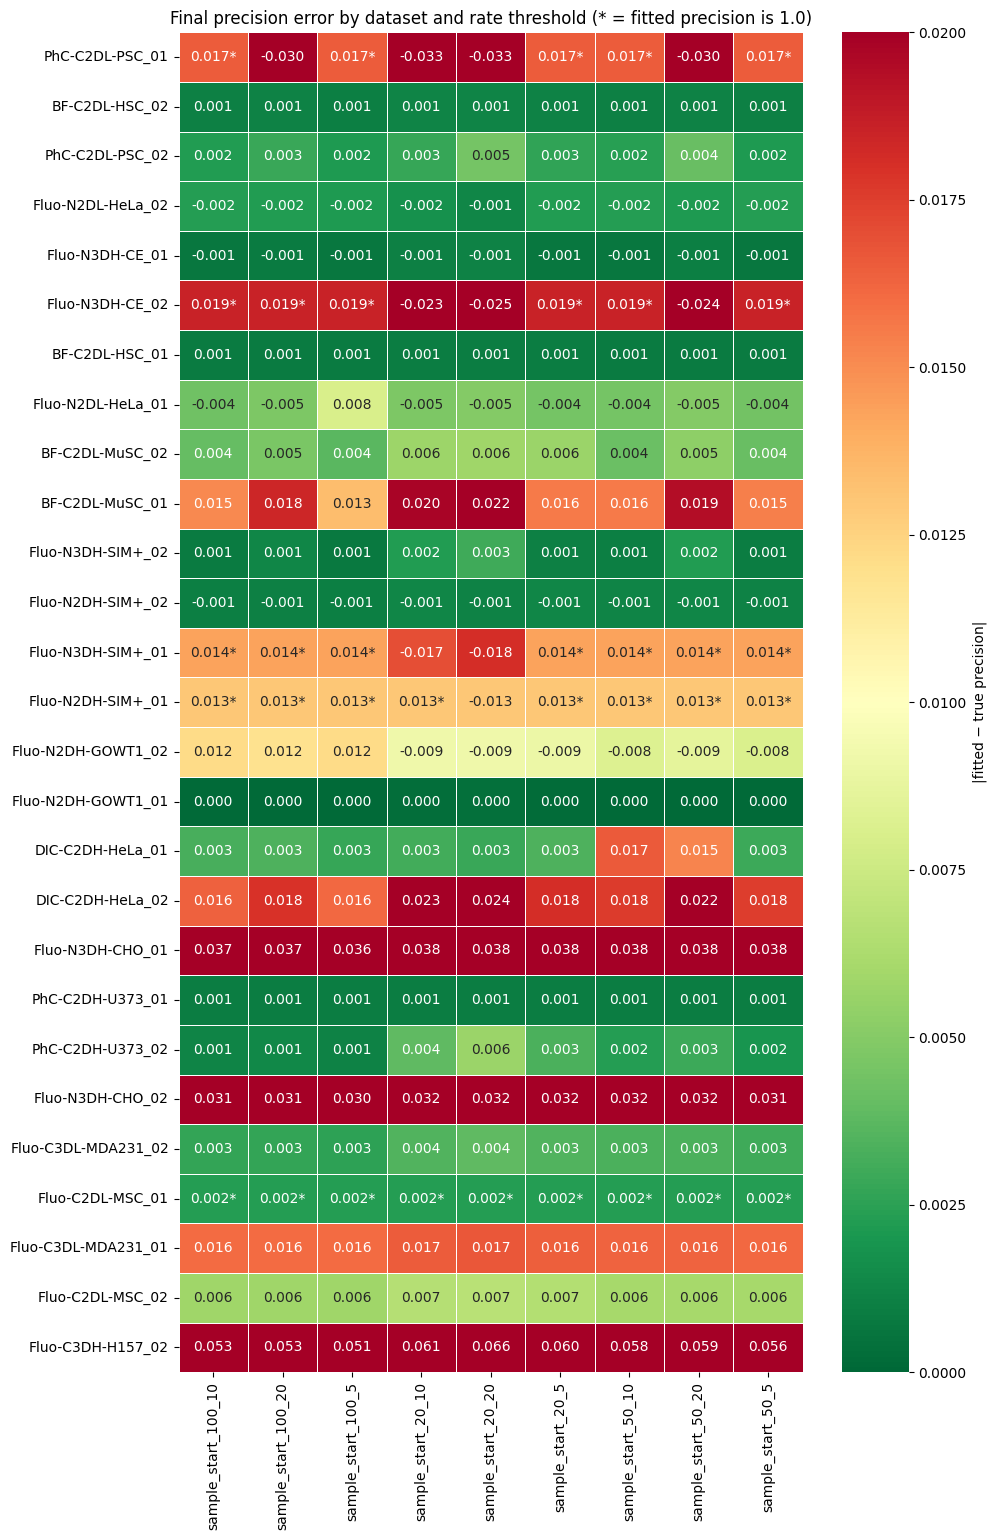

In [132]:
error_records = []

for sample_col_name, ds_start_edges in rate_dicts.items():
    for ds_name in col_order:
        mask = plot_df['ds_name'] == ds_name
        y_smooth = plot_df.loc[mask, 'smoothed_prec'].values
        x = plot_df.loc[mask, 'n_sampled'].values.astype(float)
        true_prec = plot_df.loc[mask, 'cum_prec_estimate'].values[-1]

        start_edge = ds_start_edges.get(ds_name)
        if start_edge is None:
            error_records.append({'ds_name': ds_name, 'combination': sample_col_name, 'final_error': float('nan'), 'fitted_final': float('nan')})
            continue

        start_idx = int(np.searchsorted(x, start_edge))
        x_fit = x[0:start_idx]
        y_fit_input = y_smooth[0:start_idx]

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', OptimizeWarning)
                popt, _ = curve_fit(reciprocal_func, x_fit, y_fit_input, p0=[1.0, 0.01], bounds=(0, np.inf), maxfev=10000)
            fitted_final = reciprocal_func(x[-1], *popt)
            final_error = fitted_final - true_prec
        except RuntimeError:
            fitted_final = float('nan')
            final_error = float('nan')

        error_records.append({'ds_name': ds_name, 'combination': sample_col_name, 'final_error': final_error, 'fitted_final': fitted_final})

error_heatmap = pd.DataFrame(error_records).pivot(index='ds_name', columns='combination', values='final_error').reindex(col_order)
fitted_heatmap = pd.DataFrame(error_records).pivot(index='ds_name', columns='combination', values='fitted_final').reindex(col_order)

# build string annotations: formatted error + asterisk where fitted precision == 1
def make_annot(error, fitted):
    if pd.isna(error):
        return ''
    star = '*' if np.isclose(fitted, 1.0) else ''
    return f'{error:.3f}{star}'

annot = pd.DataFrame(
    [[make_annot(error_heatmap.iloc[r, c], fitted_heatmap.iloc[r, c])
      for c in range(error_heatmap.shape[1])]
     for r in range(error_heatmap.shape[0])],
    index=error_heatmap.index,
    columns=error_heatmap.columns,
)

fig, ax = plt.subplots(figsize=(10, len(col_order) * 0.5 + 2))
sns.heatmap(error_heatmap.abs(), ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.02,
            annot=annot, fmt='', linewidths=0.5, cbar_kws={'label': '|fitted − true precision|'})
ax.set_title('Final precision error by dataset and rate threshold (* = fitted precision is 1.0)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

We can see that generally speaking, the choice of window size and error rate threshold is less important for fit than the dataset itself i.e. the shape of the original curve. Interestingly, while the best fit for some datasets e.g. PhC-C2DL-PSC_01 appears to be dependent on the choice of sample size and rolling window, we can see that in this case, the best "fit" is an estimated precision of 1. However, for our purposes, an estimated precision of 1, when we've already corrected some errors, is patently incorrect, and in fact an indicator of **poor fitting**. Taking this into account, the best overall choice is a rolling window of 20, with a 20% or 10% error rate i.e. "in the last 20 edges, the user found fewer than four (or 2) incorrect edges". This is fortuitous for us (and our biologist), as this is still a comparatively high error-rate, while still allowing us to get a reasonable precision fit. For the sake of simplicity, we use a rolling window of 20 with an error rate of 10% for continued analysis.

In [134]:
sample_col = 'sample_start_20_10'
sample_edges = pd.DataFrame([
    {'ds_name': ds_name, 'sample_start_edge': edge}
    for ds_name, edge in rate_dicts[sample_col].items()
    if ds_name in col_order
])
sample_edges = sample_edges.merge(ds_info[['ds_name', 'n_edges']], on='ds_name')
sample_edges['fraction_sampled'] = sample_edges['sample_start_edge'] / sample_edges['n_edges']
sample_edges['true_precision'] = sample_edges['ds_name'].map(
    plot_df.groupby('ds_name')['cum_prec_estimate'].last()
)
sample_edges['fitted_precision'] = sample_edges['ds_name'].map(
    fitted_heatmap[sample_col]
)
sample_edges = sample_edges.set_index('ds_name').reindex(col_order).reset_index()

sample_edges[['ds_name', 'n_edges', 'sample_start_edge', 'fraction_sampled', 'true_precision', 'fitted_precision']].style \
    .format({'fraction_sampled': '{:.1%}', 'sample_start_edge': '{:,}', 'n_edges': '{:,}',
             'true_precision': '{:.4f}', 'fitted_precision': '{:.4f}'}) \
    .set_caption(f'Edges sampled before fitting ({sample_col})')

,ds_name,n_edges,sample_start_edge,fraction_sampled,true_precision,fitted_precision
0,PhC-C2DL-PSC_01,"71,067","1,186.0",1.7%,0.9835,0.9503
1,BF-C2DL-HSC_02,"64,501",31.0,0.0%,0.9987,0.9999
2,PhC-C2DL-PSC_02,"56,775",569.0,1.0%,0.9950,0.9977
3,Fluo-N2DL-HeLa_02,"25,378",252.0,1.0%,0.9913,0.9896
4,Fluo-N3DH-CE_01,"23,785",254.0,1.1%,0.9887,0.9877
5,Fluo-N3DH-CE_02,"22,317",426.0,1.9%,0.9814,0.9582
6,BF-C2DL-HSC_01,"8,674",26.0,0.3%,0.9990,0.9998
7,Fluo-N2DL-HeLa_01,"8,602",185.0,2.2%,0.9899,0.9852
8,BF-C2DL-MuSC_02,"7,223",113.0,1.6%,0.9814,0.9872
9,BF-C2DL-MuSC_01,"5,388",83.0,1.5%,0.9742,0.9940


As we can see, it also takes a remarkably small number of edges to produce these estimates -- again good news for the annotator. Where the number of edges is "large" e.g. greater than 200, the dataset is also large, such that the fraction of edges inspected remains relatively small. In fact, with some of the datasets, we have to wonder whether this number of edges is simply too small. Let's see if we can improve the fit by requiring a minimum of 100 edges sampled.

In [152]:
MIN_SAMPLE = 100

small_sample_records = []

for ds_name in col_order:
    start_edge = rate_dicts['sample_start_20_10'].get(ds_name)
    if start_edge is None or start_edge >= MIN_SAMPLE:
        continue

    mask = plot_df['ds_name'] == ds_name
    y_smooth = plot_df.loc[mask, 'smoothed_prec'].values
    x = plot_df.loc[mask, 'n_sampled'].values.astype(float)
    true_prec = plot_df.loc[mask, 'cum_prec_estimate'].values[-1]

    def fit_up_to(end_edge):
        end_idx = int(np.searchsorted(x, end_edge))
        x_fit = x[0:end_idx]
        y_fit = y_smooth[0:end_idx]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', OptimizeWarning)
                popt, _ = curve_fit(reciprocal_func, x_fit, y_fit, p0=[1.0, 0.01], bounds=(0, np.inf), maxfev=10000)
            return reciprocal_func(x[-1], *popt)
        except RuntimeError:
            return float('nan')

    fitted_rate = fit_up_to(start_edge)
    fitted_100 = fit_up_to(MIN_SAMPLE)

    small_sample_records.append({
        'ds_name': ds_name,
        'n_edges': ds_info.set_index('ds_name').loc[ds_name, 'n_edges'],
        'sample_start_20_10': int(start_edge),
        'true_precision': true_prec,
        'fitted_rate': fitted_rate,
        'fitted_100': fitted_100,
        'abs_error_rate': abs(fitted_rate - true_prec),
        'abs_error_100': abs(fitted_100 - true_prec),
    })

small_sample_df = pd.DataFrame(small_sample_records).set_index('ds_name')

display_df = small_sample_df[['n_edges', 'sample_start_20_10', 'true_precision',
                              'fitted_rate', 'fitted_100', 'abs_error_rate', 'abs_error_100']]

def highlight_better(row):
    styles = [''] * len(row)
    col_names = list(row.index)
    rate_i = col_names.index('abs_error_rate')
    h100_i = col_names.index('abs_error_100')
    if pd.isna(row['abs_error_rate']) or pd.isna(row['abs_error_100']):
        pass
    elif row['abs_error_rate'] <= row['abs_error_100']:
        styles[rate_i] = 'background-color: green'
    else:
        styles[h100_i] = 'background-color: green'
    return styles

display_df.style     .format({
        'n_edges': '{:,}',
        'sample_start_20_10': '{:,}',
        'true_precision': '{:.4f}',
        'fitted_rate': '{:.4f}',
        'fitted_100': '{:.4f}',
        'abs_error_rate': '{:.4f}',
        'abs_error_100': '{:.4f}',
    })     .apply(highlight_better, axis=1).set_caption(f'Datasets with sample_start_20_10 < {MIN_SAMPLE}: comparing fit at rate threshold vs {MIN_SAMPLE} edges (green = better fit)')


,n_edges,sample_start_20_10,true_precision,fitted_rate,fitted_100,abs_error_rate,abs_error_100
ds_name,,,,,,,
BF-C2DL-HSC_02,"64,501",31,0.9987,0.9999,0.9998,0.0012,0.0011
BF-C2DL-HSC_01,"8,674",26,0.9990,0.9998,0.9998,0.0009,0.0008
BF-C2DL-MuSC_01,"5,388",83,0.9742,0.9940,0.9936,0.0198,0.0194
Fluo-N2DH-SIM+_02,"3,371",79,0.9875,0.9862,0.9863,0.0013,0.0012
Fluo-N3DH-SIM+_01,"2,866",76,0.9857,0.9687,1.0000,0.0170,0.0143
Fluo-N2DH-SIM+_01,"2,607",69,0.9870,1.0000,1.0000,0.0130,0.0130
Fluo-N2DH-GOWT1_02,"2,287",59,0.9878,0.9785,0.9957,0.0092,0.0080
Fluo-N2DH-GOWT1_01,"2,054",29,0.9976,0.9979,0.9977,0.0003,0.0001
DIC-C2DH-HeLa_01,"1,104",36,0.9828,0.9859,0.9862,0.0031,0.0034


 As we can see, taking a minimum of 100 edges generally improves the fit, with only one dataset showing decreased performance at 4 significant figures. We will therefore continue using this benchmark, so that regardless of the method, we feed at least 100 edges for fitting. Finally, we know that fitting is particularly tricky at the beginning. We now look at whether the fit can be improved by excluding some edges from the beginning of the sample, where the precision curve is particularly volatile. 

## Excluding edges for a better fit

To avoid the volatile spikes in precision at the beginning of the data, we try to find the first set of edges in our sample from above where the average precision is monotonically increasing for the remaining sets. If we find one, we only use values beyond this set for fitting. If we can't find one, we simply take the whole sample again. We test bin sizes starting from 5 edges and testing all the way up to half of the total sample.

In [141]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
import pprint

def find_min_info(sampled, min_bin_size=5):
    """Find the bin size that gives us a monotonic increase in precision"""

    # test bin sizes in increments of min_bin_size up to half the length of the sampled data
    bin_sizes = np.arange(min_bin_size, len(sampled) // 2, min_bin_size)

    for bin_size in bin_sizes:
        binned_means = np.asarray([np.mean(bin_vals) for bin_vals in np.array_split(sampled, len(sampled) // bin_size)])
        
        for i in range(len(binned_means) - 1):
            bin_diff = np.diff(binned_means[i:])
            if np.all(bin_diff >= 0):
                return {
                    'bin_size': bin_size,
                    'bin_index': i,
                    'sample_start': bin_size * i,
                }
    return None

bin_info = {}
for ds_name in plot_df.ds_name.value_counts().index:
    ds_bandit_trim =  plot_df[plot_df.ds_name == ds_name]
    ds_bandit_trim.sort_values(by='n_sampled', inplace=True)

    rate_threshold_idx = int(rate_dicts['sample_start_20_10'][ds_name])
    sample_start = 0
    sample_end = rate_threshold_idx
    # take all edges to this point
    sampled_x = np.arange(sample_start, sample_end)
    try:
        sampled_y = ds_bandit_trim.iloc[sample_start:sample_end].cum_prec_estimate.values
    except IndexError:
        print(f"Not enough data for {ds_name}, skipping")
        continue
    
    # we smooth our sampled data
    sampled_x_smooth = sampled_x[:]
    sampled_y_smooth = gaussian_filter1d(sampled_y, sigma=5)

    ds_bin = find_min_info(sampled_y_smooth)
    if ds_bin is None:
        print(f"No monotonic increase found for {ds_name}, skipping")
        continue
    bin_info[ds_name] = ds_bin
pprint.pp(bin_info)

/tmp/ipykernel_233845/3179573850.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds_bandit_trim.sort_values(by='n_sampled', inplace=True)


{'PhC-C2DL-PSC_01': {'bin_size': np.int64(5),
                     'bin_index': 169,
                     'sample_start': np.int64(845)},
 'BF-C2DL-HSC_02': {'bin_size': np.int64(5),
                    'bin_index': 2,
                    'sample_start': np.int64(10)},
 'PhC-C2DL-PSC_02': {'bin_size': np.int64(5),
                     'bin_index': 81,
                     'sample_start': np.int64(405)},
 'Fluo-N2DL-HeLa_02': {'bin_size': np.int64(5),
                       'bin_index': 19,
                       'sample_start': np.int64(95)},
 'Fluo-N3DH-CE_01': {'bin_size': np.int64(5),
                     'bin_index': 15,
                     'sample_start': np.int64(75)},
 'Fluo-N3DH-CE_02': {'bin_size': np.int64(5),
                     'bin_index': 34,
                     'sample_start': np.int64(170)},
 'BF-C2DL-HSC_01': {'bin_size': np.int64(5),
                    'bin_index': 1,
                    'sample_start': np.int64(5)},
 'Fluo-N2DL-HeLa_01': {'bin_size': np.int64(5),

In [156]:
bin_fit_params = []

for ds_name in col_order:
    mask = plot_df['ds_name'] == ds_name
    y_smooth = plot_df.loc[mask, 'smoothed_prec'].values
    x = plot_df.loc[mask, 'n_sampled'].values.astype(float)
    true_prec = plot_df.loc[mask, 'cum_prec_estimate'].values[-1]

    sample_start_20_10 = rate_dicts['sample_start_20_10'].get(ds_name)
    bin_start = bin_info.get(ds_name, {}).get('sample_start', 0)

    if sample_start_20_10 is None or sample_start_20_10 <= bin_start:
        raise ValueError(f"Invalid indices for {ds_name}: sample_start_20_10: {sample_start_20_10}, bin_start: {bin_start}")

    # we saw before that at least going to 100 edges is generally better, so we do that here
    # in these cases, the user will annotate 100 edges, and we'll only use a subset for the fit.
    if sample_start_20_10 < 100:
        sample_start_20_10 = 100

    start_idx = int(np.searchsorted(x, bin_start))
    end_idx = int(np.searchsorted(x, sample_start_20_10))
    x_fit = x[start_idx:end_idx] - x[start_idx]  # shift to 0
    y_fit = y_smooth[start_idx:end_idx]

    if len(x_fit) < 3:
        raise ValueError(f"Insufficient fit values for {ds_name}: {x_fit}")

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            popt, _ = curve_fit(
                reciprocal_func,
                x_fit,
                y_fit,
                p0=[1.0, 0.01],
                bounds=(0, np.inf),
                maxfev=10000
            )
        # evaluate at final edge, shifting x accordingly
        x_final_shifted = x[-1] - x[start_idx]
        fitted_final = reciprocal_func(x_final_shifted, *popt)
        ss_res = np.sum((y_fit - reciprocal_func(x_fit, *popt)) ** 2)
        ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        final_error = fitted_final - true_prec
    except RuntimeError:
        fitted_final = float('nan')
        r2 = float('nan')
        final_error = float('nan')

    bin_fit_params.append({
        'ds_name': ds_name,
        'r2': r2,
        'fitted_final': fitted_final,
        'final_error': final_error,
        'bin_start': bin_start,
        'sample_start_20_10': sample_start_20_10,
        'edges_annotated': sample_start_20_10
    })

bin_fit_params_df = pd.DataFrame(bin_fit_params).set_index('ds_name').reindex(col_order)

# compare with previous approaches using sample_start_20_10
comparison = pd.DataFrame({
    'n_edges': ds_info.set_index('ds_name').reindex(col_order)['n_edges'],
    'edges_annotated': bin_fit_params_df['edges_annotated'],
    'true_precision': plot_df.groupby('ds_name')['cum_prec_estimate'].last().reindex(col_order),
    'error_rate_only': error_heatmap['sample_start_20_10'],
    'bin_trimmed': bin_fit_params_df['final_error'],
})
comparison['abs_error_rate_only'] = comparison['error_rate_only'].abs()
comparison['abs_bin_trimmed'] = comparison['bin_trimmed'].abs()

def highlight_better(row):
    styles = [''] * len(row)
    col_names = list(row.index)
    rate_i = col_names.index('abs_error_rate_only')
    h100_i = col_names.index('abs_bin_trimmed')
    if pd.isna(row['abs_error_rate_only']) or pd.isna(row['abs_bin_trimmed']):
        pass
    elif row['abs_error_rate_only'] <= row['abs_bin_trimmed']:
        styles[rate_i] = 'background-color: green'
    else:
        styles[h100_i] = 'background-color: green'
    return styles

comparison[['n_edges', 'edges_annotated', 'true_precision', 'error_rate_only', 'bin_trimmed', 'abs_error_rate_only', 'abs_bin_trimmed']].style     .format({
        'n_edges': '{:,}',
        'edges_annotated': '{:,}',
        'true_precision': '{:.4f}',
        'error_rate_only': '{:+.4f}',
        'bin_trimmed': '{:+.4f}',
        'abs_error_rate_only': '{:.4f}',
        'abs_bin_trimmed': '{:.4f}',
    })     .apply(highlight_better, axis=1).set_caption('Final precision error: rate-threshold fit vs. bin-trimmed fit')


,n_edges,edges_annotated,true_precision,error_rate_only,bin_trimmed,abs_error_rate_only,abs_bin_trimmed
ds_name,,,,,,,
PhC-C2DL-PSC_01,"71,067","1,186.0",0.9835,-0.0332,+0.0053,0.0332,0.0053
BF-C2DL-HSC_02,"64,501",100.0,0.9987,+0.0011,+0.0012,0.0011,0.0012
PhC-C2DL-PSC_02,"56,775",569.0,0.9950,+0.0027,+0.0045,0.0027,0.0045
Fluo-N2DL-HeLa_02,"25,378",252.0,0.9913,-0.0017,+0.0031,0.0017,0.0031
Fluo-N3DH-CE_01,"23,785",254.0,0.9887,-0.0011,+0.0039,0.0011,0.0039
Fluo-N3DH-CE_02,"22,317",426.0,0.9814,-0.0232,-0.0016,0.0232,0.0016
BF-C2DL-HSC_01,"8,674",100.0,0.9990,+0.0008,+0.0008,0.0008,0.0008
Fluo-N2DL-HeLa_01,"8,602",185.0,0.9899,-0.0047,+0.0019,0.0047,0.0019
BF-C2DL-MuSC_02,"7,223",113.0,0.9814,+0.0058,+0.0113,0.0058,0.0113


## A more representative curve

The curve we've explored so far seems to be capable of providing a "reasonable" fit